In [10]:
import pandas as pd

data = {
    "Fecha": pd.to_datetime([
        "2021-05-01", "2021-05-02", "2021-05-03", "2021-05-04", 
        "2021-05-05", "2021-05-06", "2021-05-07","2021-05-08", 
        "2021-05-09", "2021-05-10"
    ]),
    "Categoría del Producto": [
        "Balones", "Zapatillas", "Raquetas", "Camisetas", 
        "Balones", "Zapatillas", "Raquetas","Camisetas", 
        "Balones", "Zapatillas"
    ],
    "Producto": [
        "Balón de Fútbol", "Zapatillas de Fútbol", "Raqueta de Tenis", 
        "Camiseta de Entrenamiento", "Balón de Baloncesto", 
        "Zapatillas de Running", "Raqueta de Badminton","Camiseta de Fútbol", 
        "Balón de Rugby", "Zapatillas de Tenis"
    ],
    "Precio": [30, 120, 150, 25, 40, 110, 90,35, 50, 95],
    "Cantidad": [5, 2, 3, 10, 4, 1, 6,2, 3, 7],
    "Método de Pago": [
        "Tarjeta de Crédito", "PayPal", "Efectivo", 
        "Tarjeta de Crédito", "PayPal", "Efectivo", "Tarjeta de Crédito",
        "PayPal", 
        "Efectivo", "Tarjeta de Crédito"
    ],
    "Ubicación": [
        "Quito", "Guayaquil", "Cuenca", "Ambato", 
        "Quito", "Guayaquil", "Quito","Cuenca", 
        "Ambato", "Guayaquil"
    ]
}

df = pd.DataFrame(data).copy()

# Convertir la columna Fecha al tipo de dato correcto
df['Fecha'] = pd.to_datetime(df['Fecha'])

print(df)


       Fecha Categoría del Producto                   Producto  Precio  \
0 2021-05-01                Balones            Balón de Fútbol      30   
1 2021-05-02             Zapatillas       Zapatillas de Fútbol     120   
2 2021-05-03               Raquetas           Raqueta de Tenis     150   
3 2021-05-04              Camisetas  Camiseta de Entrenamiento      25   
4 2021-05-05                Balones        Balón de Baloncesto      40   
5 2021-05-06             Zapatillas      Zapatillas de Running     110   
6 2021-05-07               Raquetas       Raqueta de Badminton      90   
7 2021-05-08              Camisetas         Camiseta de Fútbol      35   
8 2021-05-09                Balones             Balón de Rugby      50   
9 2021-05-10             Zapatillas        Zapatillas de Tenis      95   

   Cantidad      Método de Pago  Ubicación  
0         5  Tarjeta de Crédito      Quito  
1         2              PayPal  Guayaquil  
2         3            Efectivo     Cuenca  
3    

In [11]:

# Creacion del DataFrame de promociones
promociones_data = {
    "Categoría del Producto": ["Balones", "Zapatillas", "Raquetas", "Camisetas"],
    "Descuento (%)": [10, 15, 5, 20]
}

df_promos = pd.DataFrame(promociones_data)

print(df_promos)


  Categoría del Producto  Descuento (%)
0                Balones             10
1             Zapatillas             15
2               Raquetas              5
3              Camisetas             20


# 1. Conversion de datos


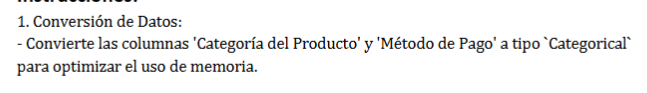


In [7]:
print(df.dtypes)
df["Categoría del Producto"]=pd.Categorical(df["Categoría del Producto"])
df["Método de Pago"]=pd.Categorical(df["Método de Pago"])
print(df.dtypes)

Fecha                     datetime64[ns]
Categoría del Producto          category
Producto                          object
Precio                             int64
Cantidad                           int64
Método de Pago                  category
Ubicación                         object
dtype: object
Fecha                     datetime64[ns]
Categoría del Producto          category
Producto                          object
Precio                             int64
Cantidad                           int64
Método de Pago                  category
Ubicación                         object
dtype: object


# 2. Analisis estadistico
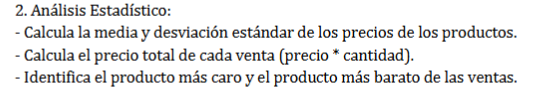


In [ ]:
media_precios=df["Precio"].mean()
desvicion_precios=df["Precio"].std
()
print(f"media: {media_precios}, desviacion: {desvicion_precios}")

media: 74.5, desviacion: 44.061194819125014


# 3. Fecha de compra
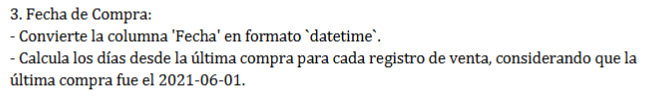

In [28]:
ulima_fecha=pd.to_datetime('2021-06-01')
df["dias_desdeUltimaCompra"]=(ulima_fecha-df["Fecha"]).dt.days

print(df)

       Fecha Categoría del Producto                   Producto  Precio  \
0 2021-05-01                Balones            Balón de Fútbol      30   
1 2021-05-02             Zapatillas       Zapatillas de Fútbol     120   
2 2021-05-03               Raquetas           Raqueta de Tenis     150   
3 2021-05-04              Camisetas  Camiseta de Entrenamiento      25   
4 2021-05-05                Balones        Balón de Baloncesto      40   
5 2021-05-06             Zapatillas      Zapatillas de Running     110   
6 2021-05-07               Raquetas       Raqueta de Badminton      90   
7 2021-05-08              Camisetas         Camiseta de Fútbol      35   
8 2021-05-09                Balones             Balón de Rugby      50   
9 2021-05-10             Zapatillas        Zapatillas de Tenis      95   

   Cantidad      Método de Pago  Ubicación  dias_desdeUltimaCompra  
0         5  Tarjeta de Crédito      Quito                      31  
1         2              PayPal  Guayaquil     

# 4. promociones y descuentos
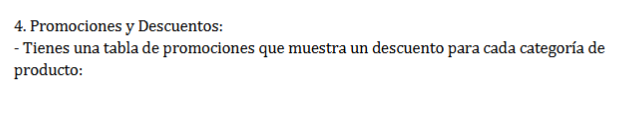
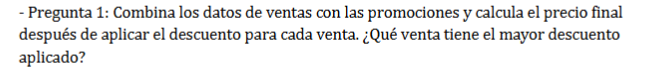

In [38]:
##hacer merge con la columna en comun, df principan y df_promos como agregado
df_concatenado=pd.merge(df,df_promos,on='Categoría del Producto',how="left")
print(df_concatenado[["Producto","Precio","Descuento (%)"]])

def descuentoAplicado(precio,descuento):
    return precio*((descuento)/100)

producto_con_mas_descuento=descuentoAplicado(df_concatenado["Precio"],df_concatenado["Descuento (%)"]).idxmax()

#localizar producto por su id
print("\n Producto con mayor descuento aplicado \n",df_concatenado.loc[producto_con_mas_descuento,:])

                    Producto  Precio  Descuento (%)
0            Balón de Fútbol      30             10
1       Zapatillas de Fútbol     120             15
2           Raqueta de Tenis     150              5
3  Camiseta de Entrenamiento      25             20
4        Balón de Baloncesto      40             10
5      Zapatillas de Running     110             15
6       Raqueta de Badminton      90              5
7         Camiseta de Fútbol      35             20
8             Balón de Rugby      50             10
9        Zapatillas de Tenis      95             15

 Producto con mayor descuento aplicado 
 Fecha                      2021-05-02 00:00:00
Categoría del Producto              Zapatillas
Producto                  Zapatillas de Fútbol
Precio                                     120
Cantidad                                     2
Método de Pago                          PayPal
Ubicación                            Guayaquil
dias_desdeUltimaCompra                      30
Descuento 

# 5. limpieza Datos
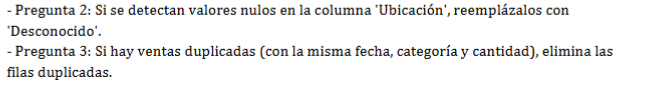

In [ ]:
print(len(df_concatenado))

df_concatenado["Ubicación"]=df_concatenado["Ubicación"].fillna("Desconocido")
df_concatenado["Ubicación"]=df_concatenado["Ubicación"].drop_duplicates()

print(len(df_concatenado))

### en este caso no hay duplicados


10
10


## 6. Operaciones Avanzadas
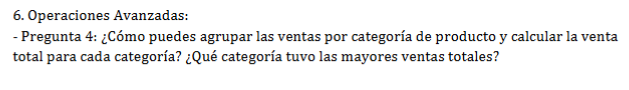



In [47]:
df_concatenado["ventaTotalProducto"]=df_concatenado["Precio"]*df_concatenado["Cantidad"]

df_porCategorias=df_concatenado.groupby("Categoría del Producto")[["Cantidad","ventaTotalProducto"]].sum()

print(df_porCategorias, f"\n Categoria producto con mayores ventas: {df_porCategorias['ventaTotalProducto'].idxmax}\n")

                        Cantidad  ventaTotalProducto
Categoría del Producto                              
Balones                       12                 460
Camisetas                     12                 320
Raquetas                       9                 990
Zapatillas                    10                1015 
 Categoria producto con mayores ventas: <bound method Series.idxmax of Categoría del Producto
Balones        460
Camisetas      320
Raquetas       990
Zapatillas    1015
Name: ventaTotalProducto, dtype: int64>



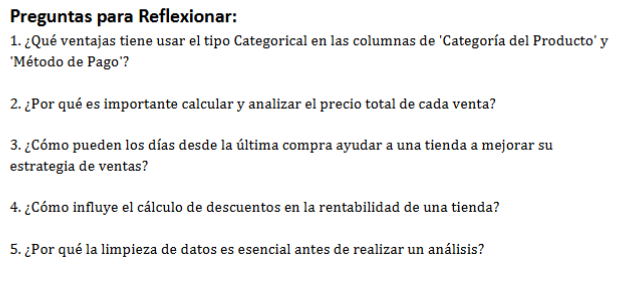


1. mayor rendimiento, menos espacio de memoria
2. para saber en realidad cual producto es que mas ingresos genera
3. supongo para gestionar el stock del producto
4. para saber si aplicando descuentos se vende mas
5. no comprometer la calidad de los datos ni las conslusiones y posteriormente en desiciontes materiales
